# Josué Uril Martínez Ruíz

Colab: https://colab.research.google.com/drive/1xfiy0cxMx0rUooxxk_IrPzCveV3I7V-c?usp=sharing

Drive: https://colab.research.google.com/drive/1xfiy0cxMx0rUooxxk_IrPzCveV3I7V-c?usp=sharing

GitHub: https://github.com/josue-mtz/Deeplearning-para-vision-por-computadoras

<div align="center">

  <a href="https://www.ultralytics.com/yolo/yolo27?utm_source=github&utm_medium=social&utm_campaign=yolo27-launch-2026&utm_content=banner" target="_blank">
    <img width="1024", src="https://raw.githubusercontent.com/ultralytics/assets/main/yolov8/banner-yolov8.png"></a>

  [中文](https://docs.ultralytics.com/zh) | [한국어](https://docs.ultralytics.com/ko) | [日本語](https://docs.ultralytics.com/ja) | [Русский](https://docs.ultralytics.com/ru) | [Deutsch](https://docs.ultralytics.com/de) | [Français](https://docs.ultralytics.com/fr) | [Español](https://docs.ultralytics.com/es) | [Português](https://docs.ultralytics.com/pt) | [Türkçe](https://docs.ultralytics.com/tr) | [Tiếng Việt](https://docs.ultralytics.com/vi) | [العربية](https://docs.ultralytics.com/ar)

  <a href="https://github.com/ultralytics/ultralytics/actions/workflows/ci.yml"><img src="https://github.com/ultralytics/ultralytics/actions/workflows/ci.yml/badge.svg" alt="Ultralytics CI"></a>
  <a href="https://clickpy.clickhouse.com/dashboard/ultralytics"><img src="https://static.pepy.tech/badge/ultralytics" alt="Ultralytics Downloads"></a>
  <a href="https://discord.com/invite/ultralytics"><img alt="Ultralytics Discord" src="https://img.shields.io/discord/1089800235347353640?logo=discord&logoColor=white&label=Discord&color=blue"></a>
  <a href="https://community.ultralytics.com"><img alt="Ultralytics Forums" src="https://img.shields.io/discourse/users?server=https%3A%2F%2Fcommunity.ultralytics.com&logo=discourse&label=Forums&color=blue"></a>
  <a href="https://www.reddit.com/r/ultralytics/"><img alt="Ultralytics Reddit" src="https://img.shields.io/reddit/subreddit-subscribers/ultralytics?style=flat&logo=reddit&logoColor=white&label=Reddit&color=blue"></a>
  <br>
  <a href="https://console.paperspace.com/github/ultralytics/notebooks/blob/main/notebooks/how-to-monitor-workouts-using-ultralytics-yolo.ipynb"><img src="https://assets.paperspace.io/img/gradient-badge.svg" alt="Run Ultralytics on Gradient"></a>
  <a href="https://colab.research.google.com/github/ultralytics/notebooks/blob/main/notebooks/how-to-monitor-workouts-using-ultralytics-yolo.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Ultralytics In Colab"></a>
  <a href="https://www.kaggle.com/models/ultralytics/yolo26"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open Ultralytics In Kaggle"></a>
  <a href="https://mybinder.org/v2/gh/ultralytics/notebooks/HEAD?labpath=notebooks%2Fhow-to-monitor-workouts-using-ultralytics-yolo.ipynb"><img src="https://mybinder.org/badge_logo.svg" alt="Open Ultralytics In Binder"></a>

  Welcome to the Workouts monitoring using Ultralytics YOLO26 🚀 notebook! <a href="https://github.com/ultralytics/ultralytics">YOLO26</a> is the latest version of the YOLO (You Only Look Once) AI models developed by <a href="https://www.ultralytics.com">Ultralytics</a>. We hope that the resources in this notebook will help you get the most out of YOLO26. Please browse the YOLO26 <a href="https://docs.ultralytics.com">Docs</a> for details, raise an issue on <a href="https://github.com/ultralytics/ultralytics">GitHub</a> for support, and join our <a href="https://ultralytics.com/discord">Discord</a> community for questions and discussions!</div>

# Monitor Workouts using Ultralytics YOLO26

This notebook serves as a starting point for [monitoring workouts](https://docs.ultralytics.com/guides/workouts-monitoring) in videos or live streams using the YOLO26 model.

## What is Workout monitoring?

- Monitoring workouts through pose estimation with [Ultralytics YOLO26](https://github.com/ultralytics/ultralytics/) enhances exercise assessment by accurately tracking key body landmarks and joints in real-time. This technology provides instant feedback on exercise form, tracks workout routines, and measures performance metrics, optimizing training sessions for users and trainers alike.

## Advantages of Workouts Monitoring?

- **Optimized Performance:** Tailoring workouts based on monitoring data for better results.
- **Goal Achievement:** Track and adjust fitness goals for measurable progress.
- **Personalization:** Customized workout plans based on individual data for effectiveness.
- **Health Awareness:** Early detection of patterns indicating health issues or over-training.
- **Informed Decisions:** Data-driven decisions for adjusting routines and setting realistic goals.

## Setup

pip install `ultralytics` and [dependencies](https://github.com/ultralytics/ultralytics/blob/main/pyproject.toml) and check software and hardware.

[![PyPI - Version](https://img.shields.io/pypi/v/ultralytics?logo=pypi&logoColor=white)](https://pypi.org/project/ultralytics/) [![Downloads](https://static.pepy.tech/badge/ultralytics)](https://clickpy.clickhouse.com/dashboard/ultralytics) [![PyPI - Python Version](https://img.shields.io/pypi/pyversions/ultralytics?logo=python&logoColor=gold)](https://pypi.org/project/ultralytics/)

In [ ]:
!uv pip install ultralytics

import cv2
import ultralytics
from ultralytics import solutions
from ultralytics.utils.downloads import safe_download

!apt-get install -y ffmpeg  # for video writing properly
ultralytics.checks()

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.4/112.6 GB disk)


## Exercises list

Ultralytics supports various workout exercises, including sample videos for some exercises. We will start by downloading these videos for use later in the notebook.

- Legextension
- Legpress
- Squats
- Pushups

In [ ]:
exercises_list = ["Legextension", "Legpress", "Squats", "Pushups"]

for exercise in exercises_list:
    safe_download(f"https://github.com/ultralytics/assets/releases/download/v0.0.0/{exercise}.demo.video.mp4")

## KeyPoints Map

This keypoint map allows you to adjust the keypoints for monitoring workouts. Using these keypoints, various workout exercises can be effectively tracked and analyzed.

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<img align="left" src="https://github.com/ultralytics/docs/releases/download/0/keypoints-order-ultralytics-yolov8-pose.avif" width="480">

## Arguments `AIGym`

| Name         | Type    | Default | Description                                                                            |
| ------------ | ------- | ------- | -------------------------------------------------------------------------------------- |
| `kpts`       | `list`  | `None`  | List of three keypoints index, for counting specific workout, followed by keypoint Map |
| `line_width` | `int`   | `2`     | Thickness of the lines drawn.                                                          |
| `show`       | `bool`  | `False` | Flag to display the image.                                                             |
| `up_angle`   | `float` | `145.0` | Angle threshold for the 'up' pose.                                                     |
| `down_angle` | `float` | `90.0`  | Angle threshold for the 'down' pose.                                                   |
| `model`      | `str`   | `None`  | Path to Ultralytics YOLO Pose Model File                                               |

## Push-ups counting

Push-up counting tracks the number of push-ups performed by detecting the body's movement in each frame. It ensures accurate rep counting and can assess form based on joint angles for improved workout tracking.

In [ ]:
cap = cv2.VideoCapture("Pushups.demo.video.mp4")
assert cap.isOpened(), "Error reading video file"

# Video writer
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))
video_writer = cv2.VideoWriter("Pushups.demo.video.output.avi", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

# Init AIGym
gym = solutions.AIGym(
    show=True,  # Display the frame
    kpts=[5, 7, 9],  # keypoints index of person for monitoring specific exercise, by default it's for pushup
    model="yolo26n-pose.pt",  # Path to the YOLO26 pose estimation model file
    line_width=4,  # Adjust the line width for bounding boxes and text display
    verbose=False,
)

# Process video
while cap.isOpened():
    success, im0 = cap.read()
    if not success:
        print("Video frame is empty or video processing has been successfully completed.")
        break
    results = gym(im0)  # monitor workouts on each frame
    video_writer.write(results.plot_im)  # write the output frame in file.

video_writer.release()

Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo26n-pose.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'show_boxes': True, 'region': None, 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90.0, 'kpts': [5, 7, 9], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 4, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': True, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'quantize': None, 'imgsz': 640, 'tracker': 'tracktrack.yaml', 'verbose': False, 'data': 'images'}
Video frame is empty or video processing has been successfully completed.


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<img align="left" src="https://github.com/user-attachments/assets/bd2f6eec-7ec7-4063-b05a-5bcb9f62622c" width="720">

## Monitor your Squats

Squat counting tracks the number of squats performed by detecting the movement of the body in each frame. It ensures accurate rep counting and evaluates form by monitoring the angle of the knees and hips for proper technique.


In [ ]:
cap = cv2.VideoCapture("Squats.demo.video.mp4")
assert cap.isOpened(), "Error reading video file"

# Video writer
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))
video_writer = cv2.VideoWriter("Squats.demo.video.output.avi", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

# Init AIGym
gym = solutions.AIGym(
    show=True,  # Display the frame
    kpts=[5, 11, 13],  # keypoints index of person for monitoring specific exercise, by default it's for pushup
    model="yolo26m-pose.pt",  # Path to the YOLO26 pose estimation model file
    line_width=4,  # Adjust the line width for bounding boxes and text display
    verbose=False,
)

# Process video
while cap.isOpened():
    success, im0 = cap.read()
    if not success:
        print("Video frame is empty or video processing has been successfully completed.")
        break
    results = gym(im0)  # monitor workouts on each frame
    video_writer.write(results.plot_im)  # write the output frame in file.

video_writer.release()

Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo26m-pose.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'show_boxes': True, 'region': None, 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90.0, 'kpts': [5, 11, 13], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 4, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': True, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'quantize': None, 'imgsz': 640, 'tracker': 'tracktrack.yaml', 'verbose': False, 'data': 'images'}
Video frame is empty or video processing has been successfully completed.


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<img align="left" src="https://github.com/user-attachments/assets/4c0e92a1-a204-467c-92ad-4d58add38efa" width="720">

## Legpress Monitoring

Leg press counting tracks the number of reps by detecting leg movement and monitoring knee and hip angles. It ensures accurate counting and proper form during the exercise.

In [ ]:
cap = cv2.VideoCapture("Legpress.demo.video.mp4")
assert cap.isOpened(), "Error reading video file"

# Video writer
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))
video_writer = cv2.VideoWriter("Legpress.demo.video.output.avi", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

# Init AIGym
gym = solutions.AIGym(
    show=True,  # Display the frame
    kpts=[11, 13, 15],  # keypoints index of person for monitoring specific exercise, by default it's for pushup
    model="yolo26x-pose.pt",  # Path to the YOLO26 pose estimation model file
    line_width=4,  # Adjust the line width for bounding boxes and text display
    up_angle=140,
    down_angle=120,
    verbose=False,
)

# Process video
while cap.isOpened():
    success, im0 = cap.read()
    if not success:
        print("Video frame is empty or video processing has been successfully completed.")
        break
    results = gym(im0)  # monitor workouts on each frame
    video_writer.write(results.plot_im)  # write the output frame in file.

video_writer.release()

Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo26x-pose.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'show_boxes': True, 'region': None, 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 140, 'down_angle': 120, 'kpts': [11, 13, 15], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 4, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': True, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'quantize': None, 'imgsz': 640, 'tracker': 'tracktrack.yaml', 'verbose': False, 'data': 'images'}
Video frame is empty or video processing has been successfully completed.


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<img align="left" src="https://github.com/user-attachments/assets/be76f50c-44d7-4141-b88e-c9d711be277b" width="720">

## Monitor Legextension

Leg extension counting tracks the number of reps by detecting the movement of the legs as they extend against the resistance. It monitors the knee and hip angles to ensure accurate counting and proper form throughout the exercise.

In [ ]:
cap = cv2.VideoCapture("Legextension.demo.video.mp4")
assert cap.isOpened(), "Error reading video file"

# Video writer
w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))
video_writer = cv2.VideoWriter("Legextension.demo.video.output.avi", cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

# Init AIGym
gym = solutions.AIGym(
    show=True,  # Display the frame
    kpts=[12, 14, 16],  # keypoints index of person for monitoring specific exercise, by default it's for pushup
    model="yolo26m-pose.pt",  # Path to the YOLO26 pose estimation model file
    line_width=4,  # Adjust the line width for bounding boxes and text display
    verbose=False,
)

# Process video
while cap.isOpened():
    success, im0 = cap.read()
    if not success:
        print("Video frame is empty or video processing has been successfully completed.")
        break
    results = gym(im0)  # monitor workouts on each frame
    video_writer.write(results.plot_im)  # write the output frame in file.

video_writer.release()

Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo26m-pose.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'show_boxes': True, 'region': None, 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90.0, 'kpts': [12, 14, 16], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 4, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': True, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'quantize': None, 'imgsz': 640, 'tracker': 'tracktrack.yaml', 'verbose': False, 'data': 'images'}
Video frame is empty or video processing has been successfully completed.


&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
<img align="left" src="https://github.com/user-attachments/assets/5f20438c-dce7-48d0-abd0-0dc6bc1285c7" width="720">

Crafted with 💙 by [Ultralytics](https://www.ultralytics.com)  

🌟 Explore and star the [Ultralytics Notebooks](https://github.com/ultralytics/notebooks/) to supercharge your AI journey! 🚀


# Visualización de los resultados de cada ejercicio

El siguiente bloque de código lee un fotograma intermedio de los videos procesados y los muestra en una cuadrícula.

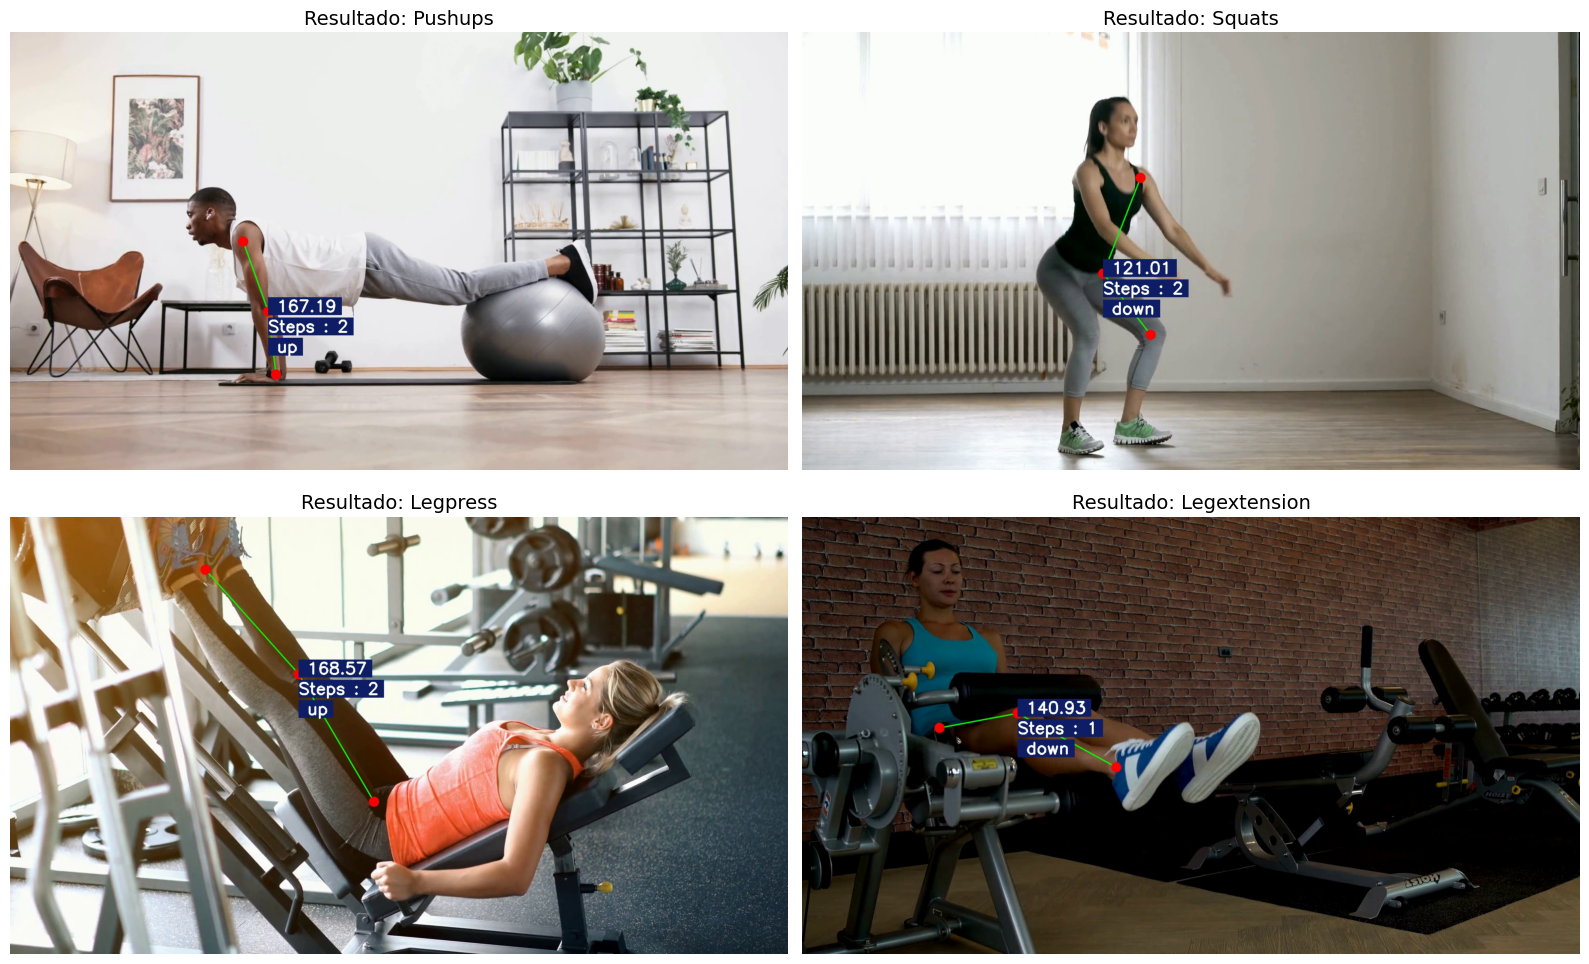

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Lista de los videos resultantes de salida
output_videos = [
    ("Pushups", "Pushups.demo.video.output.avi"),
    ("Squats", "Squats.demo.video.output.avi"),
    ("Legpress", "Legpress.demo.video.output.avi"),
    ("Legextension", "Legextension.demo.video.output.avi")
]

# Configurar la cuadrícula de visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i, (title, video_path) in enumerate(output_videos):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"No se pudo abrir el video: {video_path}")
        axes[i].text(0.5, 0.5, f"Error cargando\n{title}", ha='center', va='center')
        axes[i].axis('off')
        continue

    # Obtener el número total de fotogramas y leer uno intermedio (por ejemplo, a la mitad del video)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)

    success, frame = cap.read()
    if success:
        # Convertir de BGR (OpenCV) a RGB (Matplotlib)
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame_rgb)
        axes[i].set_title(f"Resultado: {title}", fontsize=14)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"No se pudo extraer fotograma\n{title}", ha='center', va='center')
        axes[i].axis('off')

    cap.release()

plt.tight_layout()
plt.show()

### Reproducción animada de los resultados en tiempo real

Reproducir cualquier video de salida fotograma a fotograma directamente dentro de Colab.

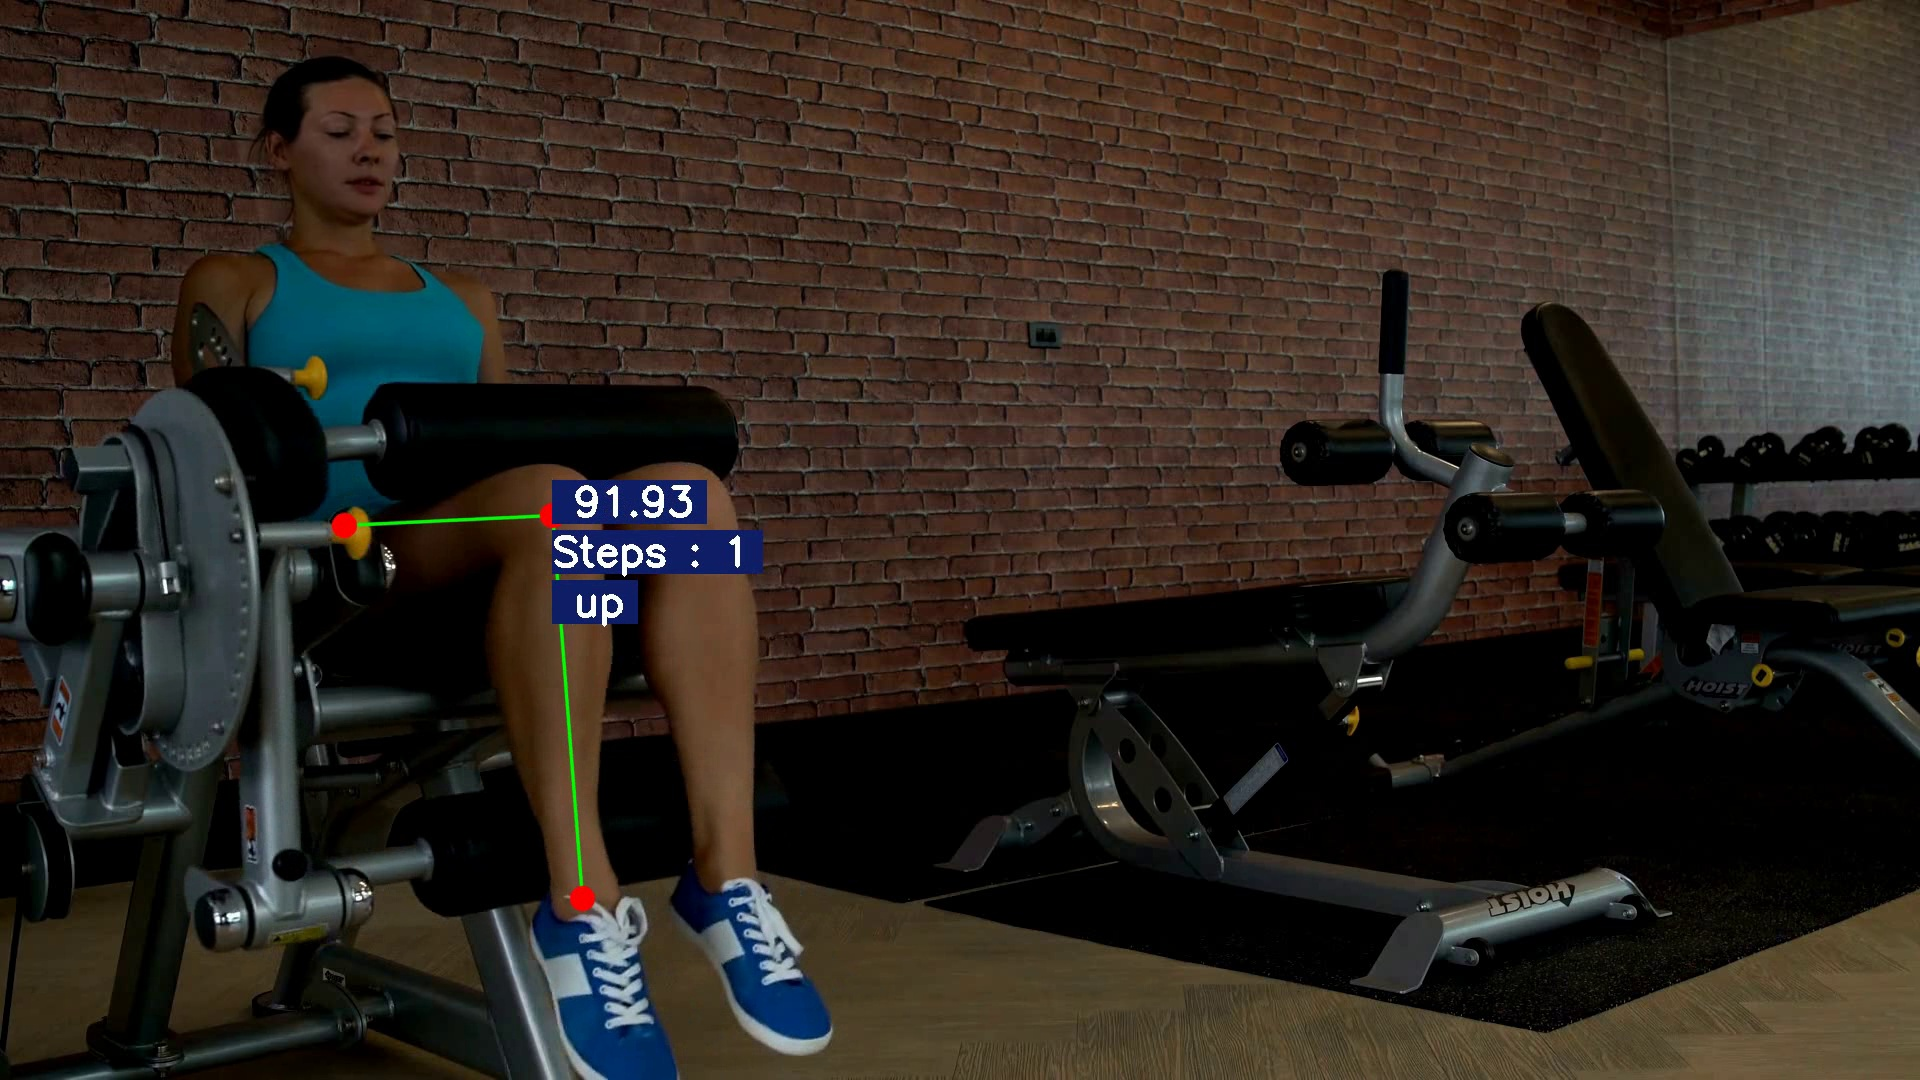

Reproducción finalizada.


In [ ]:
import cv2
import time
from IPython.display import display, Image, clear_output

# Elige el video a reproducir:
# "Pushups.demo.video.output.avi", "Squats.demo.video.output.avi",
# "Legpress.demo.video.output.avi", "Legextension.demo.video.output.avi"
video_elegido = "Legextension.demo.video.output.avi"

cap = cv2.VideoCapture(video_elegido)
assert cap.isOpened(), f"No se pudo abrir el video: {video_elegido}"

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # Codificar el fotograma a formato JPG para mostrarlo
        _, buffer = cv2.imencode('.jpg', frame)

        # Limpiar la salida anterior y mostrar el nuevo fotograma
        clear_output(wait=True)
        display(Image(data=buffer.tobytes()))

        # Un pequeño retraso para controlar la velocidad de reproducción
        time.sleep(0.03)

except KeyboardInterrupt:
    # Permite detener la reproducción manualmente sin lanzar un error largo
    print("Reproducción pausada por el usuario.")

finally:
    cap.release()
    print("Reproducción finalizada.")

#Videos de ejemplos desde Google Drive

Descargo los videos del drive, proceso y visualizamos los videos que has compartido desde tu Google Drive.

In [ ]:
import gdown
import os

# Enlaces y IDs de Google Drive aportados
videos_drive = {
    "Legextension_custom.mp4": "1RN7n-6FaXwJPOdZ9StW1HbIms3bDfT-Q",
    "Legpress_custom.mp4": "1bbdrp611HAl3mO2MBH4Ezh-fEgVfzIJk",
    "Pushups_custom.mp4": "1FmvTx2lSnqynlmiynPx4nsAGbQgZwYJq",
    "Squats_custom.mp4": "1GKPP4elIPXhCXilvc_xl0bCc8eILJ-in"
}

# Descargar cada video
for nombre_archivo, drive_id in videos_drive.items():
    url = f"https://drive.google.com/uc?id={drive_id}"
    print(f"Descargando {nombre_archivo}...")
    gdown.download(url, nombre_archivo, quiet=True)

Descargando Legextension_custom.mp4...
Descargando Legpress_custom.mp4...
Descargando Pushups_custom.mp4...
Descargando Squats_custom.mp4...


### Procesamiento de los Nuevos Videos con YOLO26

Ejecutamos el análisis de pose y el conteo de repeticiones para cada uno de tus videos utilizando las mismas configuraciones que definimos previamente.

In [ ]:
import cv2
from ultralytics import solutions

# Configuración de los ejercicios personalizados
ejercicios_config = {
    "Pushups_custom.mp4": {
        "output": "Pushups_custom_output.avi",
        "kpts": [5, 7, 9],
        "model": "yolo26n-pose.pt",
        "up_angle": 145.0,
        "down_angle": 90.0
    },
    "Squats_custom.mp4": {
        "output": "Squats_custom_output.avi",
        "kpts": [5, 11, 13],
        "model": "yolo26m-pose.pt",
        "up_angle": 145.0,
        "down_angle": 90.0
    },
    "Legpress_custom.mp4": {
        "output": "Legpress_custom_output.avi",
        "kpts": [11, 13, 15],
        "model": "yolo26x-pose.pt",
        "up_angle": 140.0,
        "down_angle": 120.0
    },
    "Legextension_custom.mp4": {
        "output": "Legextension_custom_output.avi",
        "kpts": [12, 14, 16],
        "model": "yolo26m-pose.pt",
        "up_angle": 145.0,
        "down_angle": 90.0
    }
}

for video_entrada, config in ejercicios_config.items():
    if not os.path.exists(video_entrada):
        print(f"Archivo {video_entrada} no encontrado, saltando...")
        continue

    print(f"Procesando {video_entrada} -> {config['output']}...")
    cap = cv2.VideoCapture(video_entrada)
    w, h, fps = (int(cap.get(x)) for x in (cv2.CAP_PROP_FRAME_WIDTH, cv2.CAP_PROP_FRAME_HEIGHT, cv2.CAP_PROP_FPS))
    video_writer = cv2.VideoWriter(config["output"], cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    gym = solutions.AIGym(
        show=True,
        kpts=config["kpts"],
        model=config["model"],
        line_width=4,
        up_angle=config.get("up_angle", 145.0),
        down_angle=config.get("down_angle", 90.0),
        verbose=False
    )

    while cap.isOpened():
        success, im0 = cap.read()
        if not success:
            break
        results = gym(im0)
        video_writer.write(results.plot_im)

    cap.release()
    video_writer.release()
    print(f"¡{video_entrada} procesado con éxito!")

Procesando Pushups_custom.mp4 -> Pushups_custom_output.avi...
Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo26n-pose.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'show_boxes': True, 'region': None, 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90.0, 'kpts': [5, 7, 9], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 4, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': True, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'quantize': None, 'imgsz': 640, 'tracker': 'tracktrack.yaml', 'verbose': False, 'data': 'images'}
¡Pushups_custom.mp4 procesado con éxito!
Procesando Squats_custom.mp4 -> Squats_custom_output.avi...
Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo26m-pose.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'show_boxes': True

### Reproductor para tus videos personalizados

Elige uno de los videos procesados deseas ver en acción seleccionando el nombre correspondiente.

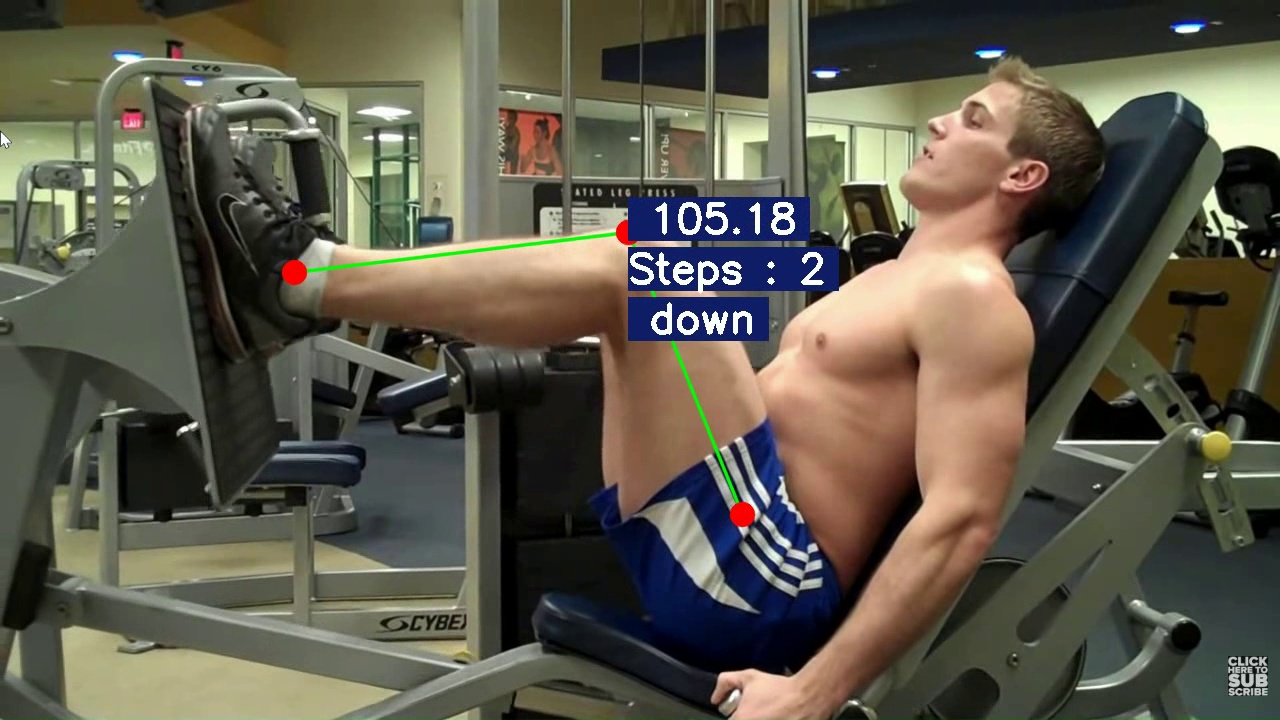

Reproducción finalizada.


In [ ]:
import cv2
import time
from IPython.display import display, Image, clear_output

# Puedes cambiar este nombre para reproducir tus otros videos completados, por ejemplo:
# "Pushups_custom_output.avi" o "Squats_custom_output.avi"
# "Legextension_custom_output.avi" o "Legpress_custom_output.avi"
mi_video_elegido = "Legpress_custom_output.avi"

cap = cv2.VideoCapture(mi_video_elegido)
assert cap.isOpened(), f"No se pudo abrir el video: {mi_video_elegido}"

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        _, buffer = cv2.imencode('.jpg', frame)
        clear_output(wait=True)
        display(Image(data=buffer.tobytes()))
        time.sleep(0.03)

except KeyboardInterrupt:
    print("Reproducción pausada por el usuario.")

finally:
    cap.release()
    print("Reproducción finalizada.")

### Resultados de los videos de Google Drive

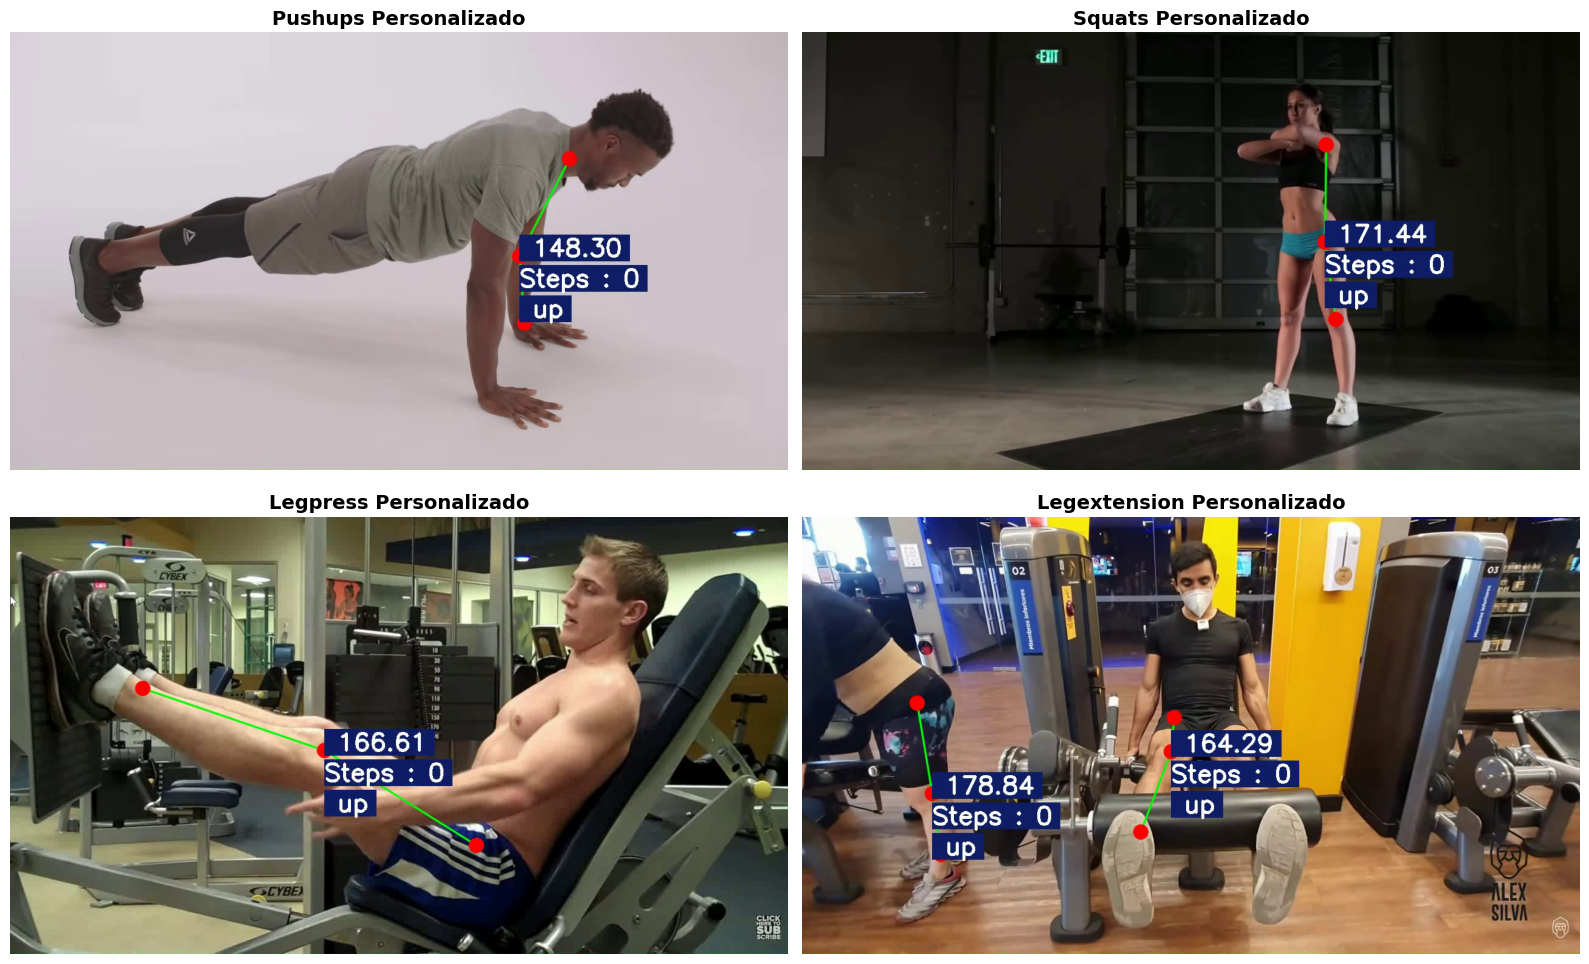

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Videos personalizados procesados
mis_videos_resultados = [
    ("Pushups Personalizado", "Pushups_custom_output.avi"),
    ("Squats Personalizado", "Squats_custom_output.avi"),
    ("Legpress Personalizado", "Legpress_custom_output.avi"),
    ("Legextension Personalizado", "Legextension_custom_output.avi")
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for i, (titulo, ruta_video) in enumerate(mis_videos_resultados):
    cap = cv2.VideoCapture(ruta_video)
    if not cap.isOpened():
        axes[i].text(0.5, 0.5, f"No se pudo cargar\n{titulo}", ha='center', va='center')
        axes[i].axis('off')
        continue

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # Nos posicionamos en la mitad del video para capturar la acción
    cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)

    success, frame = cap.read()
    if success:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame_rgb)
        axes[i].set_title(titulo, fontsize=14, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"Error leyendo fotograma\n{titulo}", ha='center', va='center')
        axes[i].axis('off')
    cap.release()

plt.tight_layout()
plt.show()

# Detección de Ejercicios con la Cámara Web

Capturar la señal de tu webcam en el navegador, la envía a Python para que el modelo YOLO26 Pose analice tu postura, y te devuelve el video anotado en tiempo real.

<IPython.core.display.Javascript object>

Ultralytics Solutions: ✅ {'source': None, 'model': 'yolo26n-pose.pt', 'classes': None, 'show_conf': True, 'show_labels': True, 'show_boxes': True, 'region': None, 'colormap': 21, 'show_in': True, 'show_out': True, 'up_angle': 145.0, 'down_angle': 90.0, 'kpts': [5, 7, 9], 'analytics_type': 'line', 'figsize': (12.8, 7.2), 'blur_ratio': 0.5, 'vision_point': (20, 20), 'crop_dir': 'cropped-detections', 'json_file': None, 'line_width': 4, 'records': 5, 'fps': 30.0, 'max_hist': 5, 'meter_per_pixel': 0.05, 'max_speed': 120, 'show': False, 'iou': 0.7, 'conf': 0.25, 'device': None, 'max_det': 300, 'quantize': None, 'imgsz': 640, 'tracker': 'tracktrack.yaml', 'verbose': False, 'data': 'images'}
Cámara iniciada. Presiona 'Interrumpir Ejecución' en Colab para detener la cámara.


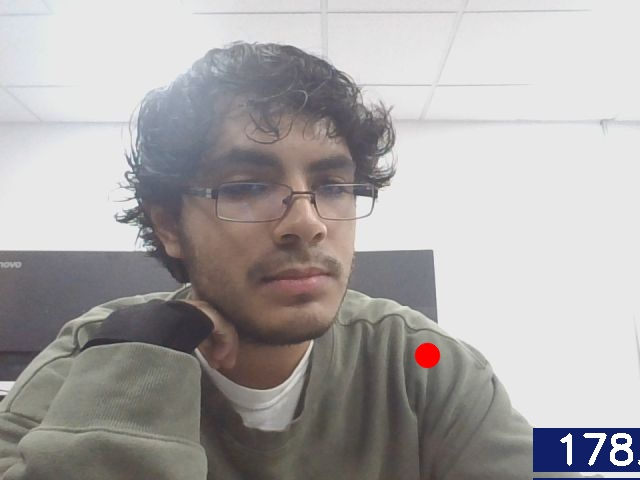

WARNING ⚠️ No tracks found.
WARNING ⚠️ No tracks found.
WARNING ⚠️ No tracks found.
Flujo de cámara detenido por el usuario.
Cámara web apagada correctamente.


In [ ]:
import io
import cv2
import base64
import numpy as np
from PIL import Image as PILImage
from google.colab.output import eval_js
from IPython.display import display, Javascript, Image as IPImage
from ultralytics import solutions

# Código JavaScript para inicializar y transmitir el feed de la cámara web
js_webcam_code = """
var video;
var canvas;
var ctx;
var stream;

async function startWebcam() {
  video = document.createElement('video');
  video.style.display = 'block';
  stream = await navigator.mediaDevices.getUserMedia({video: {width: 640, height: 480}});

  document.body.appendChild(video);
  video.srcObject = stream;
  await video.play();

  canvas = document.createElement('canvas');
  canvas.width = video.videoWidth;
  canvas.height = video.videoHeight;
  ctx = canvas.getContext('2d');
}

async function captureFrame() {
  ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
  let imgData = canvas.toDataURL('image/jpeg', 0.8);
  return imgData;
}

function stopWebcam() {
  if (stream) {
    stream.getTracks().forEach(track => track.stop());
  }
  if (video) {
    video.remove();
  }
}
"""

# Cargar las funciones JavaScript en el navegador
display(Javascript(js_webcam_code))

# Inicializar el modelo AIGym para flexiones (Pushups)
gym_webcam = solutions.AIGym(
    show=False,  # No necesitamos ventana externa
    kpts=[5, 7, 9],  # Keypoints para Pushups (Hombro, Codo, Muñeca)
    model="yolo26n-pose.pt",
    line_width=4,
    up_angle=145.0,
    down_angle=90.0,
    verbose=False
)

try:
  # Iniciar la cámara en el navegador
  eval_js('startWebcam()')
  print("Cámara iniciada. Presiona 'Interrumpir Ejecución' en Colab para detener la cámara.")

  # Contenedor para ir mostrando la imagen procesada
  output_display = display(display_id=True)

  while True:
    # Capturar fotograma de JS
    js_frame = eval_js('captureFrame()')
    if not js_frame:
      break

    # Decodificar la imagen JPEG base64 a formato OpenCV / numpy
    img_bytes = base64.b64decode(js_frame.split(',')[1])
    img_pil = PILImage.open(io.BytesIO(img_bytes))
    frame = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

    # Procesar con AIGym de YOLO
    results = gym_webcam(frame)
    annotated_frame = results.plot_im

    # Convertir de vuelta a JPEG para mostrarlo en el navegador
    _, buffer = cv2.imencode('.jpg', annotated_frame)
    encoded_img = base64.b64encode(buffer).decode('utf-8')

    # Actualizar la visualización en tiempo real utilizando IPImage de forma segura
    output_display.update(IPImage(data=base64.b64decode(encoded_img)))

except KeyboardInterrupt:
  print("Flujo de cámara detenido por el usuario.")
finally:
  # Asegurar que se apague la luz de la webcam en tu laptop
  eval_js('stopWebcam()')
  print("Cámara web apagada correctamente.")